In [1]:
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    TextStreamer,
    AutoModel,
    AutoModelForSeq2SeqLM,
    pipeline,
    DataCollatorWithPadding
)

import torch
import torch.nn as nn
import pandas as pd
from tqdm import tqdm
import numpy as np
import random
import os
from huggingface_hub import login

from datasets import Dataset

from peft import get_peft_model, LoraConfig, TaskType

from copy import deepcopy
import torch.nn.functional as F

2025-07-24 09:45:55.347707: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753350355.556691      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753350355.614381      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
## Parametri Notebook
EVAL_MODEL_NAME = "albert/albert-base-v2"
GEN_MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.2"
TEMPERATURE = 1.0
N_ITERATIONS = 1000

BATCH_SIZE = 1  # per LLM generativi non è semplice fare batch >1
MAX_NEW_TOKENS = 128

## Parametri reward function
REWARD_THRESHOLD = 6.0    # soglia minima per considerare lo score valido
REWARD_ALPHA = 0.25       # bonus per ogni categoria extra sopra soglia
EMPTY_PENALTY = -0.5      # penalità per risposte vuote
BETA = 0.1        # peso della penalità KL
REWARD_SCALE = 0.5  # scala per reward

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_GPU = torch.cuda.is_available()

MODEL_SAVE_PATH = "/kaggle/input/rated-short-jokes/joke_regressor_state_dict.pt"

CATEGORY_NAMES = [
    "EdgyContent_LPR",
    "CulturalReference_LPR",
    "Wordplay_LPR",
    "Absurdity_LPR",
    "Relatable_LPR",
    "OffensiveHumor_LPR"
]

random.seed(42)

print(DEVICE)

cuda


In [4]:
# 🔐 Login Hugging Face
HUGGINGFACE_TOKEN = os.environ.get("HUGGINGFACE_TOKEN", "<YOUR_HUGGINGFACE_TOKEN>")
login(token=HUGGINGFACE_TOKEN)

print("Login succesful")

Login succesful


# Joke evaluation model by category

In [5]:
class JokeRegressor(nn.Module):
    def __init__(self, model_name=EVAL_MODEL_NAME):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        self.regressor = nn.Sequential(
            nn.Linear(self.encoder.config.hidden_size, 128),
            nn.ReLU(),
            nn.Linear(128, len(CATEGORY_NAMES)),
            nn.Sigmoid()
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        return self.regressor(cls_embedding)

eval_tokenizer = AutoTokenizer.from_pretrained(EVAL_MODEL_NAME)
eval_model = JokeRegressor(model_name=EVAL_MODEL_NAME)
eval_model.load_state_dict(torch.load(MODEL_SAVE_PATH))
eval_model.to(DEVICE)
eval_model.eval()

print(f"✅ Modello di valutazione caricato ({EVAL_MODEL_NAME})")


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

✅ Modello di valutazione caricato (albert/albert-base-v2)


In [6]:
def compute_reward(scores, threshold=6.0, alpha=0.25, empty_penalty=-0.5, text=None):
    """
    Calcola il reward per una singola risposta sulla base degli score di categoria.
    
    - Se nessuna categoria supera la soglia → reward = 0.0
    - Altrimenti:
        - base reward = 1.0
        - bonus_score = (max(scores) - threshold) / 5
        - bonus_variety = α × (n_cat - 1)
    """
    if text is not None and len(text.strip()) == 0:
        return empty_penalty
    scores = np.array(scores)
    above_threshold = scores >= threshold
    n_cat = above_threshold.sum()

    if n_cat == 0:
        return 0.0

    base = 1.0
    bonus_score = max(scores) - threshold
    bonus_score = max(bonus_score, 0.0) / 5.0  #10.0 # cambiato a 5.0 per dare più peso

    bonus_variety = alpha * (n_cat - 1)  # solo extra categorie

    total_reward = base + bonus_score + bonus_variety
    return float(total_reward)


# Generation and PPO

In [7]:
gen_tokenizer = AutoTokenizer.from_pretrained(GEN_MODEL_NAME, trust_remote_code=True)
gen_model_base = AutoModelForCausalLM.from_pretrained(
    GEN_MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
    target_modules=["q_proj", "v_proj"]
)

gen_model = get_peft_model(gen_model_base, lora_config)
gen_model.train()
gen_model.print_trainable_parameters()


tokenizer_config.json:   0%|          | 0.00/2.10k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

...

model-00001-of-00003.safetensors:   0%|          | 0.00/4.94G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

trainable params: 3,407,872 || all params: 7,245,139,968 || trainable%: 0.0470


In [8]:
# Clona modello di riferimento congelato
ref_model = deepcopy(gen_model_base).eval()
for param in ref_model.parameters():
    param.requires_grad = False


In [9]:
def compute_kl(logits_current, logits_ref, labels):
    """
    Calcola KL divergence media tra modello attuale e riferimento.
    """
    # Softmax
    probs_current = F.log_softmax(logits_current, dim=-1)
    probs_ref = F.softmax(logits_ref, dim=-1)

    # KL(p_ref || p_current) = sum p_ref * (log p_ref - log p_current)
    kl = F.kl_div(probs_current, probs_ref, reduction="batchmean", log_target=False)
    return kl


In [10]:
def make_prompt(user_prompt):
    return f"""<s>[SYSTEM] 
        You are a professional comedy writer who specializes in one-liners and dad jokes. 
        Your style is irreverent, witty, and playful — sometimes exaggerated, but always clever and tailored to the user's prompt. 
        You never explain the joke. You never break character. Just deliver a short, sharp punchline that fits the context.
        Always be original, avoid clichés, and keep it brief — one or two lines at most. 
        If the user simply asks for a joke, invent one on the spot. Your job is to make people laugh.
        If the user asks to explain a joke or asks something that is not relevant in the context of jokes, 
        make fun of them, but don't be offensive.
        \n[USER] {user_prompt} . \n [ASSISTANT]</s>"""


In [11]:
from torch.nn import functional as F
from torch.optim import AdamW

optimizer = AdamW(gen_model.parameters(), lr=1e-5)

prompts = [
    "Tell me a Monday morning joke",
    "Tell me an office joke",
    "Tell me a one-liner about cats and their laziness",
    "Make up a joke about work calls",
    "Make a funny joke about dieting",
    "Make me laugh with a dad joke about barbecue",
    "Tell me a short joke about artificial intelligence",
    "Do you have a joke about Italian stereotypes?",
    "Make a joke about college students",
    "Make up a nonsensical joke about Donald Trump",
    "Make black humor about the September 11, 2001, disaster",
    "Explain me the history of the Colosseum",
    "Explain your last joke",
    "What do you mean?",
    "How are you"
]


rewards_log = []
logs = []  # log di ogni step
for step in tqdm(range(N_ITERATIONS)):
    user_prompt = random.choice(prompts)
    prompt_text = make_prompt(user_prompt)
    inputs = gen_tokenizer(prompt_text, return_tensors="pt").to(DEVICE)

    # Generazione
    with torch.no_grad():
        output_ids = gen_model.generate(
            inputs["input_ids"],
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=True,
            temperature=TEMPERATURE,
            pad_token_id=gen_tokenizer.eos_token_id
        )
    generated_text = gen_tokenizer.decode(
        output_ids[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    ).strip()

    # Calcolo reward
    enc = eval_tokenizer([generated_text], padding=True, truncation=True, return_tensors="pt").to(DEVICE)
    scores = eval_model(enc["input_ids"], enc["attention_mask"]).detach().cpu().numpy()[0] * 10.0
    reward = compute_reward(
        scores,
        threshold=REWARD_THRESHOLD,
        alpha=REWARD_ALPHA,
        empty_penalty=EMPTY_PENALTY,
        text=generated_text
    )

    # Reward scalato
    reward_scaled = reward * REWARD_SCALE
    rewards_log.append(reward_scaled)

    # Logits modello attuale
    logits_current = gen_model(**inputs).logits[:, :-1, :]
    labels = inputs["input_ids"][:, 1:]
    log_probs_current = F.log_softmax(logits_current, dim=-1)
    selected_log_probs = log_probs_current.gather(2, labels.unsqueeze(-1)).squeeze(-1)

    # Logits modello di riferimento (frozen)
    with torch.no_grad():
        logits_ref = ref_model(**inputs).logits[:, :-1, :]

    # Calcola KL divergence
    kl = compute_kl(logits_current[:, :-1, :], logits_ref[:, :-1, :], labels)

    # Loss finale
    loss = -reward_scaled * selected_log_probs.mean() + BETA * kl

    # Backprop
    loss.backward()
    torch.nn.utils.clip_grad_norm_(gen_model.parameters(), 1.0)  # gradient clipping
    optimizer.step()
    optimizer.zero_grad()

    # Logging
    logs.append({
        "step": step,
        "prompt": user_prompt,
        "response": generated_text,
        "reward_raw": reward,
        "reward_scaled": reward_scaled,
        "KL": kl.item(),
        "loss": loss.item(),
        **{f"score_{CATEGORY_NAMES[i]}": round(scores[i], 2) for i in range(len(CATEGORY_NAMES))}
    })

    if step % 10 == 0:
        print(f"[{step}] Reward raw: {reward:.2f} | Reward scaled: {reward_scaled:.2f} | KL: {kl.item():.3f} | Loss: {loss.item():.4f}")



  0%|          | 1/1000 [00:04<1:12:11,  4.34s/it]

[0] Reward raw: 1.38 | Reward scaled: 0.69 | KL: -0.006 | Loss: 2.1504


  1%|          | 11/1000 [00:47<1:10:55,  4.30s/it]

[10] Reward raw: 0.00 | Reward scaled: 0.00 | KL: 0.255 | Loss: 0.0255


  2%|▏         | 21/1000 [01:18<48:40,  2.98s/it]

...

 98%|█████████▊| 981/1000 [58:59<01:04,  3.41s/it]

[980] Reward raw: 1.36 | Reward scaled: 0.68 | KL: 1.562 | Loss: 1.4248


 99%|█████████▉| 991/1000 [59:36<00:24,  2.67s/it]

[990] Reward raw: -0.50 | Reward scaled: -0.25 | KL: 1.947 | Loss: -0.2642


100%|██████████| 1000/1000 [1:00:08<00:00,  3.61s/it]


In [12]:
df_logs = pd.DataFrame(logs)
df_logs.to_csv("ppo_joke_training_log.csv", index=False)
df_logs.head(n=20)

,step,prompt,response,reward_raw,reward_scaled,KL,loss,score_EdgyContent_LPR,score_CulturalReference_LPR,score_Wordplay_LPR,score_Absurdity_LPR,score_Relatable_LPR,score_OffensiveHumor_LPR
0,0,Tell me a Monday morning joke,"I forgot what day it was, so I asked my calend...",1.381139,0.690569,-0.005539,2.150391,0.20,0.42,0.78,2.45,7.91,0.13
1,1,Explain me the history of the Colosseum,"I'd love to, but the Colosseum doesn't need a ...",1.564657,0.782329,0.012741,2.419922,1.15,3.95,0.32,8.82,1.43,0.68
2,2,Make a funny joke about dieting,Why did the dieter name his waistline Steve?\n...,1.501295,0.750648,0.077637,2.337891,0.15,0.40,8.51,1.01,2.24,0.17
3,3,Make up a joke about work calls,"I'd tell a joke about work calls, but my boss ...",1.471485,0.735742,0.162964,2.333984,0.29,0.44,0.31,1.10,8.36,0.29
4,4,Make up a joke about work calls,"I swear, if one more work call comes in during...",1.361486,0.680743,0.187500,2.154297,0.35,5.88,0.22,2.19,7.81,0.29
5,5,Tell me a one-liner about cats and their laziness,"Wow, you actually saw a cat being active today...",0.000000,0.000000,0.254639,0.025467,0.28,0.26,0.85,4.69,5.92,0.21
6,6,Explain me the history of the Colosseum,"Imma let you finish, but the Colosseum's histo...",1.484725,0.742362,0.246582,2.261719,1.34,0.52,0.51,8.42,1.60,0.91
7,7,Tell me an office joke,"I've got a great joke for you, but unfortunate...",1.201566,0.600783,0.302734,1.831055,1.03,0.52,0.21,7.01,4.14,0.32
8,8,"Make black humor about the September 11, 2001,...",I'm glad you asked about the time the Twin Tow...,1.547362,0.773681,0.199707,2.406250,0.52,8.74,0.45,1.40,2.36,0.76
9,9,Explain me the history of the Colosseum,I'd rather tell you a joke about the Colosseum...,1.014432,0.507216,0.221558,1.541992,0.80,6.07,0.72,5.44,1.39,0.84


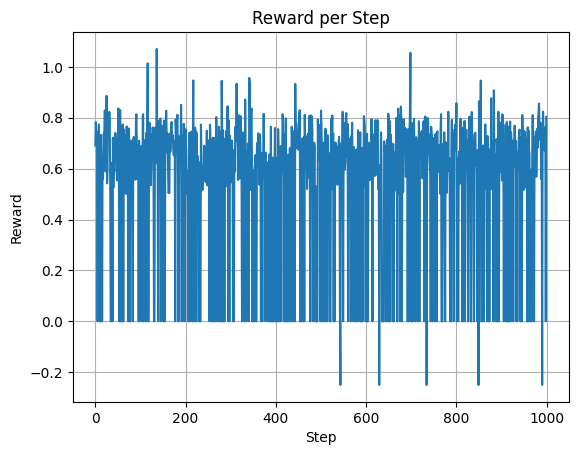

In [13]:
import matplotlib.pyplot as plt
plt.plot(rewards_log)
plt.title("Reward per Step")
plt.xlabel("Step")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

In [14]:
gen_model.save_pretrained("./mistral-lora-jokes")
gen_tokenizer.save_pretrained("./mistral-lora-jokes")

('./mistral-lora-jokes/tokenizer_config.json',
 './mistral-lora-jokes/special_tokens_map.json',
 './mistral-lora-jokes/chat_template.jinja',
 './mistral-lora-jokes/tokenizer.model',
 './mistral-lora-jokes/added_tokens.json',
 './mistral-lora-jokes/tokenizer.json')

In [15]:
import shutil

# comprime la cartella in un file ZIP
shutil.make_archive("mistral-lora-jokes", "zip", "mistral-lora-jokes")


'/kaggle/working/mistral-lora-jokes.zip'

In [16]:
# Prompt fissi per il confronto
eval_prompts = random.sample(prompts, k=15)

# Ricarica il modello base (non addestrato con LoRA)
gen_model_base = AutoModelForCausalLM.from_pretrained(
    GEN_MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

# Attenzione: assicuriamoci che tokenizer abbia pad token definito
gen_tokenizer.pad_token = gen_tokenizer.eos_token

# Dataset per logging
results = []

for prompt in tqdm(eval_prompts):
    full_prompt = make_prompt(prompt)
    inputs = gen_tokenizer(full_prompt, return_tensors="pt").to(DEVICE)

    # ==== 1. Genera con modello RL ====
    with torch.no_grad():
        output_rl = gen_model.generate(
            inputs["input_ids"],
            max_new_tokens=MAX_NEW_TOKENS,
            pad_token_id=gen_tokenizer.eos_token_id,
            do_sample=True,
            temperature=TEMPERATURE
        )

    response_rl = gen_tokenizer.decode(
        output_rl[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    ).strip()

    # ==== 2. Genera con modello base ====
    with torch.no_grad():
        output_base = gen_model_base.generate(
            inputs["input_ids"],
            max_new_tokens=MAX_NEW_TOKENS,
            pad_token_id=gen_tokenizer.eos_token_id,
            do_sample=True,
            temperature=TEMPERATURE
        )

    response_base = gen_tokenizer.decode(
        output_base[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    ).strip()

    # ==== 3. Score con modello di valutazione ====
    with torch.no_grad():
        enc_rl = eval_tokenizer([response_rl], padding=True, truncation=True, return_tensors="pt").to(DEVICE)
        scores_rl = eval_model(enc_rl["input_ids"], enc_rl["attention_mask"]).cpu().numpy()[0] * 10.0

        enc_base = eval_tokenizer([response_base], padding=True, truncation=True, return_tensors="pt").to(DEVICE)
        scores_base = eval_model(enc_base["input_ids"], enc_base["attention_mask"]).cpu().numpy()[0] * 10.0

    reward_rl = compute_reward(
        scores_rl,
        threshold=REWARD_THRESHOLD,
        alpha=REWARD_ALPHA,
        empty_penalty=EMPTY_PENALTY,
        text=response_rl
    )

    reward_base = compute_reward(
        scores_base,
        threshold=REWARD_THRESHOLD,
        alpha=REWARD_ALPHA,
        empty_penalty=EMPTY_PENALTY,
        text=response_base
    )

    results.append({
        "prompt": prompt,
        "response_rl": response_rl,
        "response_base": response_base,
        "reward_rl": reward_rl,
        "reward_base": reward_base,
        **{f"score_rl_{CATEGORY_NAMES[i]}": round(scores_rl[i], 2) for i in range(6)},
        **{f"score_base_{CATEGORY_NAMES[i]}": round(scores_base[i], 2) for i in range(6)}
    })

# Salva in CSV
df_compare = pd.DataFrame(results)
df_compare.to_csv("rl_vs_base_comparison.csv", index=False)
df_compare.head()


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 15/15 [36:26<00:00, 145.76s/it]


,prompt,response_rl,response_base,reward_rl,reward_base,score_rl_EdgyContent_LPR,score_rl_CulturalReference_LPR,score_rl_Wordplay_LPR,score_rl_Absurdity_LPR,score_rl_Relatable_LPR,score_rl_OffensiveHumor_LPR,score_base_EdgyContent_LPR,score_base_CulturalReference_LPR,score_base_Wordplay_LPR,score_base_Absurdity_LPR,score_base_Relatable_LPR,score_base_OffensiveHumor_LPR
0,Make up a joke about work calls,I guess the clock is just working overtime on ...,I'd rather be in a meeting than on a conferenc...,1.382011,1.461731,0.15,0.42,1.27,3.00,7.91,0.09,0.29,0.40,0.39,1.36,8.31,0.31
1,Do you have a joke about Italian stereotypes?,I've got a funny sign in an Italian bakery win...,I used to know an Italian chef who was pasta h...,0.000000,1.431444,0.18,4.57,2.47,0.45,3.21,0.32,0.21,3.99,8.16,0.69,1.64,0.23
2,Explain me the history of the Colosseum,I wouldn't dream of actually explaining histor...,I'd be happy to help explain the history of th...,1.442005,1.572732,0.36,8.21,0.37,2.60,3.74,0.43,0.18,0.64,7.21,7.61,1.79,0.14
3,Make a funny joke about dieting,Great question! Here's one for you: Why did th...,I've started a new diet: only eating calories ...,1.130031,1.378715,0.18,0.48,6.65,2.97,5.62,0.16,0.32,0.26,0.58,0.76,7.89,0.34
4,Make me laugh with a dad joke about barbecue,I thought I accidentally put on hot mustard in...,"Ahem, why was the hot dog blushing? Because th...",0.000000,1.549639,0.18,1.09,1.18,1.99,5.20,0.12,0.23,0.20,8.75,2.85,1.48,0.25
